# Synthetic Eval Comparison: Concat vs Top-1 kNN

Notebook для завтрашнего сравнения:

1. Выбрать 30 daily validation cases, потом переключить на 365.
2. Сгенерировать и сохранить общие sparse masks.
3. Прогнать concat ensemble и построить rank histogram.
4. Найти один ближайший train neighbor по той же mask и сравнить full-field errors.
5. Оставить placeholder для precomputed predictions из `m2m_var_100`; формат подключим отдельно.

Тяжелые ячейки выключены флагами `RUN_* = False`.

In [1]:
import csv
import json
import os
import platform
import re
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm

from synthetic_eval.metrics import ensemble_crps, interval_coverage, rank_histogram, spread_skill, weighted_mean
from synthetic_eval.observations import ObservationConfig, make_observation_mask, make_sparse_observation
from synthetic_eval.runners import ConcatRunner
from synthetic_eval.knn_baseline import masked_condition_mse, physical_mse
from utils import NpyImageDataset, channel_normalize, channel_denormalize

if platform.system() == 'Darwin':
    REPO_DIR = Path('/Users/amir/sciml/diffusion_data_assimilation')
    DATA_ROOT = Path('/Users/amir/sciml/sea_ice_data')
else:
    REPO_DIR = Path(os.environ.get('REPO_DIR', '/home'))
    DATA_ROOT = Path(os.environ.get('DATA_ROOT', '/mnt/sciml/a.sadreev/sea_ice_data'))

os.chdir(REPO_DIR)

VALID_DIR = DATA_ROOT / 'valid'
TRAIN_DIR = DATA_ROOT / 'train'
STATS_JSON = DATA_ROOT / 'train' / 'stats.json'
MASK_PATH = DATA_ROOT / 'mask_padding.npy'
PRECOMPUTED_DIR = Path('/mnt/sciml/data_assimilation/exp_for_art/april_2026/m2m_var_100')

OUTPUT_ROOT = DATA_ROOT / 'synthetic_eval_comparison'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

with open(STATS_JSON) as f:
    stats = json.load(f)
CHANNEL_MEAN = tuple(stats['mean'])
CHANNEL_STD = tuple(stats['std'])
VALID_MASK = np.load(MASK_PATH).astype(np.float32)
IMAGE_SIZE = tuple(VALID_MASK.shape)

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')

print('repo_dir       =', REPO_DIR)
print('data_root      =', DATA_ROOT)
print('valid_dir      =', VALID_DIR)
print('train_dir      =', TRAIN_DIR)
print('output_root    =', OUTPUT_ROOT)
print('device         =', DEVICE)
print('channel_mean   =', CHANNEL_MEAN)
print('channel_std    =', CHANNEL_STD)
print('image_size     =', IMAGE_SIZE)
print('precomputed    =', PRECOMPUTED_DIR)

repo_dir       = /home
data_root      = /mnt/sciml/a.sadreev/sea_ice_data
valid_dir      = /mnt/sciml/a.sadreev/sea_ice_data/valid
train_dir      = /mnt/sciml/a.sadreev/sea_ice_data/train
output_root    = /mnt/sciml/a.sadreev/sea_ice_data/synthetic_eval_comparison
device         = cuda
channel_mean   = (0.1158, 0.1153)
channel_std    = (0.3008, 0.3501)
image_size     = (320, 256)
precomputed    = /mnt/sciml/data_assimilation/exp_for_art/april_2026/m2m_var_100


## Experiment Settings

Начни с `N_CASES = 30`. Для полного года поменяй на `365`.

In [2]:
N_CASES = 30          # switch to 365 later
DAILY_STRIDE = 24     # hourly data -> one case per day
ENSEMBLE_SIZE = 5

MASK_TYPE = 'swath'   # swath, random, block
DENSITY = 0.05        # used by random/block; recorded for swath
NOISE_STD = 0.0
N_TRACKS_RANGE = (7, 7)
MASK_SEED = 20260407

CHECKPOINT_NAME = 'ema_best_model.pth'
CONCAT_RUN_DIR = None  # set explicitly if auto-search under checkpoints/** is not desired
NUM_TIMESTEPS = 50
METHOD = 'euler'

RANK_STRIDE = 16
KNN_CHANNEL_WEIGHTS = np.array([1.0, 1.0], dtype=np.float32)

RUN_CONCAT = True
RUN_KNN_TOP1 = False

RUN_TAG = f'daily{N_CASES}_m{ENSEMBLE_SIZE}_{MASK_TYPE}_tracks{N_TRACKS_RANGE[0]}-{N_TRACKS_RANGE[1]}'
OUT_DIR = OUTPUT_ROOT / RUN_TAG
MASK_DIR = OUT_DIR / 'masks'
ARRAY_DIR = OUT_DIR / 'arrays'
PLOT_DIR = OUT_DIR / 'plots'
for d in (OUT_DIR, MASK_DIR, ARRAY_DIR, PLOT_DIR):
    d.mkdir(parents=True, exist_ok=True)

print('out_dir =', OUT_DIR)
print('run_tag =', RUN_TAG)

out_dir = /mnt/sciml/a.sadreev/sea_ice_data/synthetic_eval_comparison/daily30_m5_swath_tracks7-7
run_tag = daily30_m5_swath_tracks7-7


## Select Daily Validation Cases

Выбираем индексы `0, 24, 48, ...`. Это картинки через 24 часа.

In [3]:
raw_valid_dataset = NpyImageDataset(str(VALID_DIR), preload=False, mmap_mode='r')
case_indices = np.arange(0, len(raw_valid_dataset), DAILY_STRIDE, dtype=int)[:N_CASES]
selected_cases = [
    {'local_case_index': local_idx, 'case_index': int(idx), 'file': raw_valid_dataset.files[int(idx)]}
    for local_idx, idx in enumerate(case_indices)
]

selected_path = OUT_DIR / 'selected_cases.csv'
with open(selected_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['local_case_index', 'case_index', 'file'])
    writer.writeheader()
    writer.writerows(selected_cases)

print('n_selected =', len(selected_cases))
print('first cases:')
for row in selected_cases[:5]:
    print(row)
print('last cases:')
for row in selected_cases[-5:]:
    print(row)

n_selected = 30
first cases:
{'local_case_index': 0, 'case_index': 0, 'file': 'ocean+atmosphere_24_2022-01-01_processed000.npy'}
{'local_case_index': 1, 'case_index': 24, 'file': 'ocean+atmosphere_24_2022-01-02_processed000.npy'}
{'local_case_index': 2, 'case_index': 48, 'file': 'ocean+atmosphere_24_2022-01-03_processed000.npy'}
{'local_case_index': 3, 'case_index': 72, 'file': 'ocean+atmosphere_24_2022-01-04_processed000.npy'}
{'local_case_index': 4, 'case_index': 96, 'file': 'ocean+atmosphere_24_2022-01-05_processed000.npy'}
last cases:
{'local_case_index': 25, 'case_index': 600, 'file': 'ocean+atmosphere_24_2022-01-26_processed000.npy'}
{'local_case_index': 26, 'case_index': 624, 'file': 'ocean+atmosphere_24_2022-01-27_processed000.npy'}
{'local_case_index': 27, 'case_index': 648, 'file': 'ocean+atmosphere_24_2022-01-28_processed000.npy'}
{'local_case_index': 28, 'case_index': 672, 'file': 'ocean+atmosphere_24_2022-01-29_processed000.npy'}
{'local_case_index': 29, 'case_index': 696,

## Generate Shared Masks

Эти masks используются и concat-моделью, и top-1 kNN baseline. Это важно для честного сравнения.

In [4]:
mask_stack = []
mask_rows = []
for local_idx, case_idx in enumerate(case_indices):
    seed = MASK_SEED + local_idx
    rng = np.random.default_rng(seed)
    obs_config = ObservationConfig(
        mask_type=MASK_TYPE,
        density=DENSITY,
        noise_std=NOISE_STD,
        seed=seed,
        block_size=16,
        n_tracks_range=N_TRACKS_RANGE,
    )
    mask = make_observation_mask(IMAGE_SIZE, obs_config, VALID_MASK, rng)
    mask_stack.append(mask.astype(np.float32))
    np.save(MASK_DIR / f'mask_{local_idx:04d}_case{int(case_idx):06d}.npy', mask.astype(np.float32))
    mask_rows.append({
        'local_case_index': local_idx,
        'case_index': int(case_idx),
        'file': raw_valid_dataset.files[int(case_idx)],
        'seed': seed,
        'observed_fraction': float((mask * VALID_MASK).sum() / max(1.0, VALID_MASK.sum())),
    })
mask_stack = np.stack(mask_stack, axis=0)
np.save(ARRAY_DIR / 'shared_masks.npy', mask_stack)

with open(OUT_DIR / 'mask_metadata.csv', 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=list(mask_rows[0].keys()))
    writer.writeheader()
    writer.writerows(mask_rows)

print('mask_stack shape =', mask_stack.shape)
print('observed fraction mean =', np.mean([r['observed_fraction'] for r in mask_rows]))

mask_stack shape = (30, 320, 256)
observed fraction mean = 0.020142908270160357


## Concat Ensemble And Rank Histogram

Включи `RUN_CONCAT = True` в settings. Ячейка сохраняет generated ensemble и метрики. Rank histogram считается отдельно по каналам.

In [5]:
def resolve_concat_run_dir(checkpoint_name=CHECKPOINT_NAME):
    if CONCAT_RUN_DIR is not None:
        return str(CONCAT_RUN_DIR)
    candidates = sorted(REPO_DIR.glob(f'checkpoints/**/{checkpoint_name}'))
    if not candidates:
        raise FileNotFoundError(f'No {checkpoint_name} found under {REPO_DIR}/checkpoints/**')
    return str(candidates[-1].parent)

def compute_channel_metrics(ensemble, truth, valid_mask):
    mean = ensemble.mean(axis=0)
    crps = ensemble_crps(ensemble, truth)
    rows = []
    for ch, name in enumerate(['concentration', 'thickness'][:truth.shape[0]]):
        rmse = np.sqrt(weighted_mean((mean[ch] - truth[ch]) ** 2, valid_mask))
        crps_mean = weighted_mean(crps[ch], valid_mask)
        ss = spread_skill(ensemble[:, ch], truth[ch], valid_mask)
        cover = interval_coverage(ensemble[:, ch], truth[ch], levels=(0.5, 0.8, 0.9, 0.95))
        row = {'variable': name, 'rmse': rmse, 'crps': crps_mean, **ss}
        for level, hits in cover.items():
            row[f'coverage_{level}'] = weighted_mean(hits.astype(np.float64), valid_mask)
        rows.append(row)
    return rows

concat_rows = []
rank_counts = {}

if RUN_CONCAT:
    run_dir = resolve_concat_run_dir()
    print('concat_run_dir =', run_dir)
    runner = ConcatRunner(
        run_dir=run_dir,
        checkpoint_name=CHECKPOINT_NAME,
        channel_mean=CHANNEL_MEAN,
        channel_std=CHANNEL_STD,
        num_timesteps=NUM_TIMESTEPS,
        method=METHOD,
        device=DEVICE,
    )

    for local_idx, case_idx in enumerate(tqdm(case_indices, desc='concat cases')):
        x_true = np.asarray(raw_valid_dataset[int(case_idx)], dtype=np.float32)
        mask = mask_stack[local_idx]
        rng = np.random.default_rng(MASK_SEED + local_idx)
        observed = make_sparse_observation(x_true, mask, NOISE_STD, rng)
        ensemble = runner.run(x_true, mask, observed, ENSEMBLE_SIZE, seed=MASK_SEED + 100000 + local_idx)
        np.save(ARRAY_DIR / f'concat_ensemble_{local_idx:04d}_case{int(case_idx):06d}.npy', ensemble.astype(np.float32))

        for row in compute_channel_metrics(ensemble, x_true, VALID_MASK):
            row.update({'local_case_index': local_idx, 'case_index': int(case_idx), 'file': raw_valid_dataset.files[int(case_idx)]})
            concat_rows.append(row)

        rank_mask = VALID_MASK[::RANK_STRIDE, ::RANK_STRIDE] > 0
        for ch, name in enumerate(['concentration', 'thickness'][:x_true.shape[0]]):
            counts = rank_histogram(
                ensemble[:, ch, ::RANK_STRIDE, ::RANK_STRIDE],
                x_true[ch, ::RANK_STRIDE, ::RANK_STRIDE],
                seed=MASK_SEED + local_idx + ch,
                weights_mask=rank_mask,
            )
            rank_counts[name] = rank_counts.get(name, np.zeros_like(counts)) + counts

    with open(OUT_DIR / 'concat_per_case_metrics.csv', 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=sorted({k for r in concat_rows for k in r}))
        writer.writeheader()
        writer.writerows(concat_rows)
    np.savez_compressed(ARRAY_DIR / 'concat_rank_histograms.npz', **rank_counts)
    print('saved concat metrics:', OUT_DIR / 'concat_per_case_metrics.csv')
else:
    print('RUN_CONCAT is False')

concat_run_dir = /home/checkpoints/run_20260305_230016


KeyboardInterrupt: 

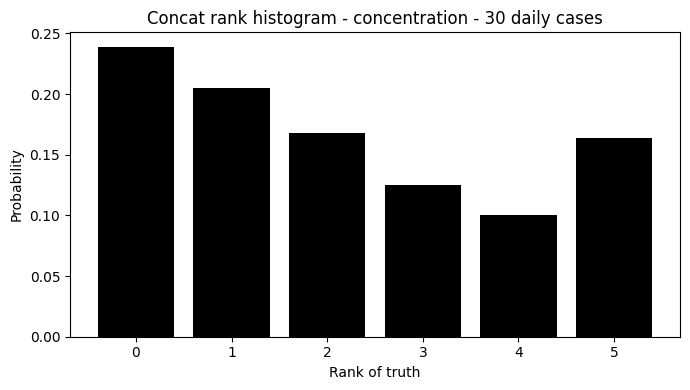

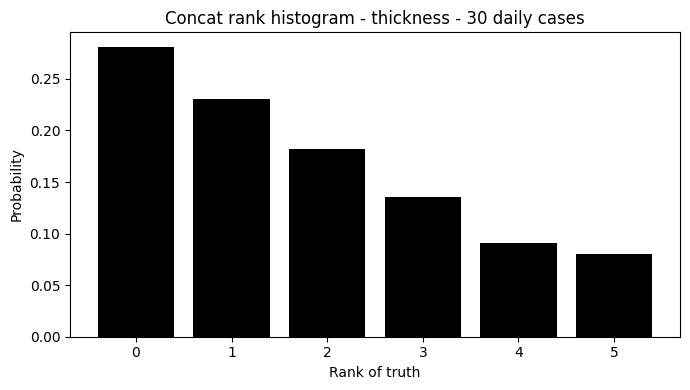

In [6]:
rank_path = ARRAY_DIR / 'concat_rank_histograms.npz'
if rank_path.exists():
    payload = np.load(rank_path)
    for name in payload.files:
        counts = payload[name].astype(np.float64)
        probs = counts / max(1.0, counts.sum())
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(np.arange(probs.size), probs, color='black')
        ax.set_title(f'Concat rank histogram - {name} - {N_CASES} daily cases')
        ax.set_xlabel('Rank of truth')
        ax.set_ylabel('Probability')
        fig.tight_layout()
        fig.savefig(PLOT_DIR / f'concat_rank_hist_{name}.png', dpi=140)
        plt.show()
else:
    print('No concat rank histogram yet:', rank_path)

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path

concat_sample_rows = []
concat_mean_rows = []

ensemble_files = sorted(ARRAY_DIR.glob('concat_ensemble_*.npy'))
print('n ensemble files =', len(ensemble_files))

for local_idx, case_idx in enumerate(case_indices[:len(ensemble_files)]):
    truth = np.asarray(raw_valid_dataset[int(case_idx)], dtype=np.float32)
    ensemble_path = ensemble_files[local_idx]
    ensemble = np.load(ensemble_path)  # (M, C, H, W)

    valid = VALID_MASK.astype(bool)
    c = min(truth.shape[0], ensemble.shape[1])
    truth_c = truth[:c]

    # Per-member MSE
    for member_idx in range(ensemble.shape[0]):
        sample = ensemble[member_idx, :c]
        row = {
            'local_case_index': int(local_idx),
            'case_index': int(case_idx),
            'file': raw_valid_dataset.files[int(case_idx)],
            'member_idx': int(member_idx),
            'ensemble_file': ensemble_path.name,
        }

        diff_all = sample[:, valid] - truth_c[:, valid]
        row['mse_all_channels'] = float(np.mean(diff_all ** 2))
        row['rmse_all_channels'] = float(np.sqrt(row['mse_all_channels']))

        for ch in range(c):
            diff_ch = sample[ch, valid] - truth_c[ch, valid]
            row[f'mse_ch{ch}'] = float(np.mean(diff_ch ** 2))
            row[f'rmse_ch{ch}'] = float(np.sqrt(row[f'mse_ch{ch}']))

        concat_sample_rows.append(row)

    # Ensemble mean MSE
    ens_mean = ensemble[:, :c].mean(axis=0)
    mean_row = {
        'local_case_index': int(local_idx),
        'case_index': int(case_idx),
        'file': raw_valid_dataset.files[int(case_idx)],
        'ensemble_file': ensemble_path.name,
        'n_members': int(ensemble.shape[0]),
    }

    diff_all = ens_mean[:, valid] - truth_c[:, valid]
    mean_row['mse_all_channels'] = float(np.mean(diff_all ** 2))
    mean_row['rmse_all_channels'] = float(np.sqrt(mean_row['mse_all_channels']))

    for ch in range(c):
        diff_ch = ens_mean[ch, valid] - truth_c[ch, valid]
        mean_row[f'mse_ch{ch}'] = float(np.mean(diff_ch ** 2))
        mean_row[f'rmse_ch{ch}'] = float(np.sqrt(mean_row[f'mse_ch{ch}']))

    concat_mean_rows.append(mean_row)

concat_member_mse = pd.DataFrame(concat_sample_rows)
concat_mean_mse = pd.DataFrame(concat_mean_rows)

display(concat_member_mse.head())
display(concat_mean_mse.head())

member_csv = OUT_DIR / 'concat_member_mse_by_day.csv'
mean_csv = OUT_DIR / 'concat_ensemble_mean_mse_by_day.csv'

concat_member_mse.to_csv(member_csv, index=False)
concat_mean_mse.to_csv(mean_csv, index=False)

print('saved:', member_csv)
print('saved:', mean_csv)

print('\nMember mean metrics:')
print(concat_member_mse[['mse_ch0', 'rmse_ch0', 'mse_ch1', 'rmse_ch1', 'mse_all_channels', 'rmse_all_channels']].mean())

print('\nEnsemble mean metrics:')
print(concat_mean_mse[['mse_ch0', 'rmse_ch0', 'mse_ch1', 'rmse_ch1', 'mse_all_channels', 'rmse_all_channels']].mean())


n ensemble files = 30


,local_case_index,case_index,file,member_idx,ensemble_file,mse_all_channels,rmse_all_channels,mse_ch0,rmse_ch0,mse_ch1,rmse_ch1
0,0,0,ocean+atmosphere_24_2022-01-01_processed000.npy,0,concat_ensemble_0000_case000000.npy,0.007566,0.086983,0.008440,0.091870,0.006692,0.081805
1,0,0,ocean+atmosphere_24_2022-01-01_processed000.npy,1,concat_ensemble_0000_case000000.npy,0.009512,0.097532,0.008837,0.094004,0.010188,0.100937
2,0,0,ocean+atmosphere_24_2022-01-01_processed000.npy,2,concat_ensemble_0000_case000000.npy,0.008805,0.093837,0.009224,0.096042,0.008387,0.091578
3,0,0,ocean+atmosphere_24_2022-01-01_processed000.npy,3,concat_ensemble_0000_case000000.npy,0.007860,0.088656,0.008735,0.093460,0.006985,0.083576
4,0,0,ocean+atmosphere_24_2022-01-01_processed000.npy,4,concat_ensemble_0000_case000000.npy,0.009730,0.098640,0.011122,0.105463,0.008337,0.091309


,local_case_index,case_index,file,ensemble_file,n_members,mse_all_channels,rmse_all_channels,mse_ch0,rmse_ch0,mse_ch1,rmse_ch1
0,0,0,ocean+atmosphere_24_2022-01-01_processed000.npy,concat_ensemble_0000_case000000.npy,5,0.005557,0.074543,0.006424,0.080152,0.004689,0.068476
1,1,24,ocean+atmosphere_24_2022-01-02_processed000.npy,concat_ensemble_0001_case000024.npy,5,0.005614,0.074927,0.006250,0.079059,0.004978,0.070554
2,2,48,ocean+atmosphere_24_2022-01-03_processed000.npy,concat_ensemble_0002_case000048.npy,5,0.008714,0.093347,0.010587,0.102893,0.006840,0.082705
3,3,72,ocean+atmosphere_24_2022-01-04_processed000.npy,concat_ensemble_0003_case000072.npy,5,0.009966,0.099831,0.009633,0.098149,0.010299,0.101485
4,4,96,ocean+atmosphere_24_2022-01-05_processed000.npy,concat_ensemble_0004_case000096.npy,5,0.010717,0.103525,0.010952,0.104654,0.010482,0.102383


saved: /mnt/sciml/a.sadreev/sea_ice_data/synthetic_eval_comparison/daily30_m5_swath_tracks7-7/concat_member_mse_by_day.csv
saved: /mnt/sciml/a.sadreev/sea_ice_data/synthetic_eval_comparison/daily30_m5_swath_tracks7-7/concat_ensemble_mean_mse_by_day.csv

Member mean metrics:
mse_ch0              0.013066
rmse_ch0             0.113159
mse_ch1              0.017490
rmse_ch1             0.129575
mse_all_channels     0.015278
rmse_all_channels    0.122044
dtype: float64

Ensemble mean metrics:
mse_ch0              0.008624
rmse_ch0             0.092112
mse_ch1              0.011558
rmse_ch1             0.104757
mse_all_channels     0.010091
rmse_all_channels    0.099042
dtype: float64


In [8]:
concat_member_mse_extrema = (
    concat_member_mse
    .groupby(['local_case_index', 'case_index', 'file'], as_index=False)
    .agg(
        min_mse_ch0=('mse_ch0', 'min'),
        max_mse_ch0=('mse_ch0', 'max'),
        mean_mse_ch0=('mse_ch0', 'mean'),
        std_mse_ch0=('mse_ch0', 'std'),

        min_rmse_ch0=('rmse_ch0', 'min'),
        max_rmse_ch0=('rmse_ch0', 'max'),
        mean_rmse_ch0=('rmse_ch0', 'mean'),

        min_mse_ch1=('mse_ch1', 'min'),
        max_mse_ch1=('mse_ch1', 'max'),
        mean_mse_ch1=('mse_ch1', 'mean'),
        std_mse_ch1=('mse_ch1', 'std'),

        min_mse_all_channels=('mse_all_channels', 'min'),
        max_mse_all_channels=('mse_all_channels', 'max'),
        mean_mse_all_channels=('mse_all_channels', 'mean'),
        std_mse_all_channels=('mse_all_channels', 'std'),
    )
)

display(concat_member_mse_extrema)

out_csv = OUT_DIR / 'concat_member_mse_extrema_by_day.csv'
concat_member_mse_extrema.to_csv(out_csv, index=False)
print('saved:', out_csv)


,local_case_index,case_index,file,min_mse_ch0,max_mse_ch0,mean_mse_ch0,std_mse_ch0,min_rmse_ch0,max_rmse_ch0,mean_rmse_ch0,min_mse_ch1,max_mse_ch1,mean_mse_ch1,std_mse_ch1,min_mse_all_channels,max_mse_all_channels,mean_mse_all_channels,std_mse_all_channels
0,0,0,ocean+atmosphere_24_2022-01-01_processed000.npy,0.008440,0.011122,0.009272,0.001072,0.091870,0.105463,0.096168,0.006692,0.010188,0.008118,0.001390,0.007566,0.009730,0.008695,0.000965
1,1,24,ocean+atmosphere_24_2022-01-02_processed000.npy,0.008620,0.011665,0.009760,0.001164,0.092846,0.108004,0.098657,0.006943,0.011175,0.008808,0.001852,0.007782,0.010529,0.009284,0.001152
2,2,48,ocean+atmosphere_24_2022-01-03_processed000.npy,0.011391,0.018962,0.014638,0.003104,0.106727,0.137701,0.120451,0.009224,0.015021,0.011893,0.002234,0.010307,0.015744,0.013266,0.002489
3,3,72,ocean+atmosphere_24_2022-01-04_processed000.npy,0.011542,0.016404,0.013880,0.001829,0.107433,0.128076,0.117608,0.012592,0.021672,0.018152,0.003944,0.012067,0.018337,0.016016,0.002501
4,4,96,ocean+atmosphere_24_2022-01-05_processed000.npy,0.009561,0.017486,0.015189,0.003255,0.097779,0.132235,0.122582,0.009702,0.026101,0.016522,0.007046,0.009632,0.021793,0.015855,0.004822
5,5,120,ocean+atmosphere_24_2022-01-06_processed000.npy,0.008714,0.013491,0.011655,0.001951,0.093348,0.116149,0.107638,0.008584,0.016809,0.010910,0.003394,0.008649,0.015150,0.011282,0.002476
6,6,144,ocean+atmosphere_24_2022-01-07_processed000.npy,0.008380,0.012910,0.011110,0.001742,0.091540,0.113622,0.105129,0.010268,0.011685,0.011210,0.000565,0.009781,0.012114,0.011160,0.000960
7,7,168,ocean+atmosphere_24_2022-01-08_processed000.npy,0.008008,0.009774,0.008939,0.000811,0.089485,0.098865,0.094466,0.010652,0.016998,0.012301,0.002647,0.009330,0.013360,0.010620,0.001584
8,8,192,ocean+atmosphere_24_2022-01-09_processed000.npy,0.009572,0.011650,0.010410,0.001063,0.097835,0.107936,0.101926,0.010083,0.015672,0.012901,0.002265,0.009828,0.013581,0.011656,0.001438
9,9,216,ocean+atmosphere_24_2022-01-10_processed000.npy,0.006768,0.010777,0.008399,0.001619,0.082270,0.103811,0.091317,0.007630,0.012097,0.009589,0.002128,0.007327,0.011437,0.008994,0.001828


saved: /mnt/sciml/a.sadreev/sea_ice_data/synthetic_eval_comparison/daily30_m5_swath_tracks7-7/concat_member_mse_extrema_by_day.csv


## 3d_var 

In [7]:
from pathlib import Path
import os

PRECOMPUTED_DIR = Path('/mnt/sciml/data_assimilation/exp_for_art/april_2026/m2m_var_100')

runs = sorted(PRECOMPUTED_DIR.glob('run_*'))
print('n_runs =', len(runs))
print('first 5 runs:')
for r in runs[:5]:
    print(' ', r.name)

run = runs[0]
print('\nselected run =', run)
print('\nfiles:')
for p in sorted(run.rglob('*'))[:100]:
    if p.is_file():
        print(p.relative_to(run), p.stat().st_size)


n_runs = 365
first 5 runs:
  run_2022-01-01T00:00:00+00:0
  run_2022-01-02T00:00:00+00:0
  run_2022-01-03T00:00:00+00:0
  run_2022-01-04T00:00:00+00:0
  run_2022-01-05T00:00:00+00:0

selected run = /mnt/sciml/data_assimilation/exp_for_art/april_2026/m2m_var_100/run_2022-01-01T00:00:00+00:0

files:
siconc_2022-01-01T00:00:00+00:0.npy 559928


In [8]:
from pathlib import Path
import numpy as np

run = sorted(PRECOMPUTED_DIR.glob('run_*'))[0]
print('run =', run)

for p in sorted(run.rglob('*')):
    if not p.is_file():
        continue

    print('\nFILE:', p.relative_to(run))
    print('suffix:', p.suffix)
    print('size:', p.stat().st_size)

    if p.suffix == '.npy':
        arr = np.load(p, mmap_mode='r')
        print('npy shape:', arr.shape, 'dtype:', arr.dtype)

    elif p.suffix == '.npz':
        z = np.load(p)
        print('npz keys:', list(z.keys()))
        for k in z.keys():
            a = z[k]
            print(' ', k, 'shape:', a.shape, 'dtype:', a.dtype)


run = /mnt/sciml/data_assimilation/exp_for_art/april_2026/m2m_var_100/run_2022-01-01T00:00:00+00:0

FILE: siconc_2022-01-01T00:00:00+00:0.npy
suffix: .npy
size: 559928
npy shape: (1, 311, 225) dtype: float64


In [9]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

PRECOMPUTED_DIR = Path('/mnt/sciml/data_assimilation/exp_for_art/april_2026/m2m_var_100')
TARGET_HW = (320, 256)

# Если в run-папке много файлов и авто-выбор берет не тот, задай явно, например:
# PRED_FILE_GLOB = '**/analysis*.npy'
# NPZ_KEY = 'prediction'
PRED_FILE_GLOB = '**/*'
NPZ_KEY = None

DATE_RE = re.compile(r'(20\d{2}-\d{2}-\d{2})')

def parse_date_from_name(name):
    m = DATE_RE.search(str(name))
    return m.group(1) if m else None

def to_channel_first(arr):
    arr = np.asarray(arr)
    arr = np.squeeze(arr)

    if arr.ndim == 2:
        return arr[None, ...].astype(np.float32)

    if arr.ndim == 3:
        if arr.shape[0] in (1, 2, 3):
            return arr.astype(np.float32)
        if arr.shape[-1] in (1, 2, 3):
            return np.moveaxis(arr, -1, 0).astype(np.float32)

    if arr.ndim == 4:
        # If ensemble/time dimension exists, take first item for deterministic comparison.
        arr = arr[0]
        return to_channel_first(arr)

    raise ValueError(f'Unsupported prediction shape: {arr.shape}')

def pad_or_crop_2d(x, target_hw=TARGET_HW):
    h, w = x.shape
    th, tw = target_hw

    # Center crop if too large.
    if h > th:
        top = (h - th) // 2
        x = x[top:top + th, :]
        h = th
    if w > tw:
        left = (w - tw) // 2
        x = x[:, left:left + tw]
        w = tw

    # Center pad if too small.
    pad_h = th - h
    pad_w = tw - w
    before_h = pad_h // 2
    after_h = pad_h - before_h
    before_w = pad_w // 2
    after_w = pad_w - before_w

    return np.pad(
        x,
        ((before_h, after_h), (before_w, after_w)),
        mode='constant',
        constant_values=np.nan,
    )

def pad_or_crop_field(field, target_hw=TARGET_HW):
    field = to_channel_first(field)
    return np.stack([pad_or_crop_2d(field[ch], target_hw) for ch in range(field.shape[0])], axis=0)

def load_prediction_from_run(run_dir):
    files = [p for p in sorted(run_dir.glob(PRED_FILE_GLOB)) if p.is_file()]
    files = [p for p in files if p.suffix in ('.npy', '.npz')]

    if not files:
        raise FileNotFoundError(f'No .npy/.npz prediction files found in {run_dir}')

    for p in files:
        try:
            if p.suffix == '.npy':
                arr = np.load(p)
                return pad_or_crop_field(arr), p

            if p.suffix == '.npz':
                z = np.load(p)
                key = NPZ_KEY or list(z.keys())[0]
                arr = z[key]
                return pad_or_crop_field(arr), p

        except Exception as exc:
            print('skip', p.relative_to(run_dir), exc)

    raise RuntimeError(f'Could not load any prediction from {run_dir}')

def build_valid_by_date(dataset):
    out = {}
    for idx, name in enumerate(dataset.files):
        d = parse_date_from_name(name)
        if d is not None and d not in out:
            out[d] = (idx, name)
    return out

valid_by_date = build_valid_by_date(raw_valid_dataset)
runs = sorted(PRECOMPUTED_DIR.glob('run_*'))

rows = []
examples = []

for run_dir in runs:
    run_date = parse_date_from_name(run_dir.name)
    if run_date not in valid_by_date:
        continue

    case_idx, valid_name = valid_by_date[run_date]
    truth = np.asarray(raw_valid_dataset[case_idx], dtype=np.float32)

    pred, pred_path = load_prediction_from_run(run_dir)

    # Match channel count.
    c = min(truth.shape[0], pred.shape[0])
    truth_c = truth[:c]
    pred_c = pred[:c]

    valid = VALID_MASK.astype(bool)
    finite = np.isfinite(pred_c).all(axis=0) & valid

    row = {
        'date': run_date,
        'case_index': int(case_idx),
        'valid_file': valid_name,
        'run_dir': run_dir.name,
        'pred_file': str(pred_path.relative_to(run_dir)),
        'pred_shape_after_pad': tuple(pred.shape),
        'n_valid_pixels': int(finite.sum()),
    }

    diff = pred_c[:, finite] - truth_c[:, finite]
    row['mse_all_channels'] = float(np.mean(diff ** 2))
    row['rmse_all_channels'] = float(np.sqrt(row['mse_all_channels']))

    for ch in range(c):
        dch = pred_c[ch, finite] - truth_c[ch, finite]
        row[f'mse_ch{ch}'] = float(np.mean(dch ** 2))
        row[f'rmse_ch{ch}'] = float(np.sqrt(row[f'mse_ch{ch}']))

    rows.append(row)

    if len(examples) < 3:
        examples.append((run_date, truth_c, pred_c, finite))

precomputed_compare = pd.DataFrame(rows)
display(precomputed_compare.head())
print('n_matched_days =', len(precomputed_compare))

out_csv = OUT_DIR / 'precomputed_m2m_var_100_metrics.csv'
precomputed_compare.to_csv(out_csv, index=False)
print('saved:', out_csv)


,date,case_index,valid_file,run_dir,pred_file,pred_shape_after_pad,n_valid_pixels,mse_all_channels,rmse_all_channels,mse_ch0,rmse_ch0
0,2022-01-01,0,ocean+atmosphere_24_2022-01-01_processed000.npy,run_2022-01-01T00:00:00+00:0,siconc_2022-01-01T00:00:00+00:0.npy,"(1, 320, 256)",46367,0.068554,0.261827,0.068554,0.261827
1,2022-01-02,24,ocean+atmosphere_24_2022-01-02_processed000.npy,run_2022-01-02T00:00:00+00:0,siconc_2022-01-02T00:00:00+00:0.npy,"(1, 320, 256)",46367,0.062767,0.250534,0.062767,0.250534
2,2022-01-03,48,ocean+atmosphere_24_2022-01-03_processed000.npy,run_2022-01-03T00:00:00+00:0,siconc_2022-01-03T00:00:00+00:0.npy,"(1, 320, 256)",46367,0.038593,0.196450,0.038593,0.196450
3,2022-01-04,72,ocean+atmosphere_24_2022-01-04_processed000.npy,run_2022-01-04T00:00:00+00:0,siconc_2022-01-04T00:00:00+00:0.npy,"(1, 320, 256)",46367,0.038985,0.197447,0.038985,0.197447
4,2022-01-05,96,ocean+atmosphere_24_2022-01-05_processed000.npy,run_2022-01-05T00:00:00+00:0,siconc_2022-01-05T00:00:00+00:0.npy,"(1, 320, 256)",46367,0.040788,0.201961,0.040788,0.201961


n_matched_days = 365
saved: /mnt/sciml/a.sadreev/sea_ice_data/synthetic_eval_comparison/daily30_m5_swath_tracks7-7/precomputed_m2m_var_100_metrics.csv


In [11]:
every_30th_mse_ch0 = precomputed_compare.iloc[::30][
    ['date', 'case_index', 'valid_file', 'pred_file', 'mse_ch0', 'rmse_ch0']
].copy()

every_30th_mse_ch0 = every_30th_mse_ch0.reset_index(names='original_row')

display(every_30th_mse_ch0)

out_csv = OUT_DIR / 'precomputed_m2m_var_100_mse_ch0_every30th.csv'
every_30th_mse_ch0.to_csv(out_csv, index=False)
print('saved:', out_csv)


,original_row,date,case_index,valid_file,pred_file,mse_ch0,rmse_ch0
0,0,2022-01-01,0,ocean+atmosphere_24_2022-01-01_processed000.npy,siconc_2022-01-01T00:00:00+00:0.npy,0.068554,0.261827
1,30,2022-01-31,720,ocean+atmosphere_24_2022-01-31_processed000.npy,siconc_2022-01-31T00:00:00+00:0.npy,0.034444,0.185590
2,60,2022-03-02,1440,ocean+atmosphere_24_2022-03-02_processed000.npy,siconc_2022-03-02T00:00:00+00:0.npy,0.038581,0.196420
3,90,2022-04-01,2160,ocean+atmosphere_24_2022-04-01_processed000.npy,siconc_2022-04-01T00:00:00+00:0.npy,0.029570,0.171959
4,120,2022-05-01,2880,ocean+atmosphere_24_2022-05-01_processed000.npy,siconc_2022-05-01T00:00:00+00:0.npy,0.040992,0.202464
5,150,2022-05-31,3600,ocean+atmosphere_24_2022-05-31_processed000.npy,siconc_2022-05-31T00:00:00+00:0.npy,0.071945,0.268226
6,180,2022-06-30,4320,ocean+atmosphere_24_2022-06-30_processed000.npy,siconc_2022-06-30T00:00:00+00:0.npy,0.075357,0.274512
7,210,2022-07-30,5040,ocean+atmosphere_24_2022-07-30_processed000.npy,siconc_2022-07-30T00:00:00+00:0.npy,0.000000,0.000000
8,240,2022-08-29,5760,ocean+atmosphere_24_2022-08-29_processed000.npy,siconc_2022-08-29T00:00:00+00:0.npy,0.000000,0.000000
9,270,2022-09-28,6480,ocean+atmosphere_24_2022-09-28_processed000.npy,siconc_2022-09-28T00:00:00+00:0.npy,0.000000,0.000000


saved: /mnt/sciml/a.sadreev/sea_ice_data/synthetic_eval_comparison/daily30_m5_swath_tracks7-7/precomputed_m2m_var_100_mse_ch0_every30th.csv


## Quick Comparison Table

После запуска concat и kNN эта ячейка покажет краткое сравнение mean errors.

In [ ]:
def read_csv_rows(path):
    if not Path(path).exists():
        return []
    with open(path) as f:
        return list(csv.DictReader(f))

concat_csv = OUT_DIR / 'concat_per_case_metrics.csv'
knn_csv = OUT_DIR / 'knn_top1_metrics.csv'
concat_rows_disk = read_csv_rows(concat_csv)
knn_rows_disk = read_csv_rows(knn_csv)

if concat_rows_disk:
    for variable in sorted(set(r['variable'] for r in concat_rows_disk)):
        vals = [float(r['rmse']) for r in concat_rows_disk if r['variable'] == variable]
        print(f'concat mean RMSE {variable}: {np.mean(vals):.6g}')
else:
    print('No concat metrics yet')

if knn_rows_disk:
    print(f"top1 kNN mean MSE all channels: {np.mean([float(r['mse_all_channels']) for r in knn_rows_disk]):.6g}")
    print(f"top1 kNN mean RMSE all channels: {np.sqrt(np.mean([float(r['mse_all_channels']) for r in knn_rows_disk])):.6g}")
    for ch in (0, 1):
        key = f'mse_ch{ch}'
        print(f"top1 kNN mean RMSE ch{ch}: {np.sqrt(np.mean([float(r[key]) for r in knn_rows_disk])):.6g}")
else:
    print('No kNN metrics yet')

No concat metrics yet
No kNN metrics yet


## Precomputed Predictions Placeholder

Не проверяем сейчас. Завтра, когда будет известен формат папки `m2m_var_100`, сюда добавим loader и приведем predictions к одному из форматов:

- deterministic: `(T, C, H, W)`
- ensemble: `(T, M, C, H, W)`

После этого можно будет переиспользовать те же `compute_channel_metrics` и rank histogram functions.

In [ ]:
print('precomputed_dir placeholder =', PRECOMPUTED_DIR)
print('Format not inspected yet by request.')

precomputed_dir placeholder = /mnt/sciml/data_assimilation/exp_for_art/april_2026/m2m_var_100
Format not inspected yet by request.
